# Zaawansowany System Analizy Szachowej
## Oparty na Uczeniu ze Wzmocnieniem i Algorytmie MCTS

### Projekt Deep Learning - Notebook do Sprawozdania

#### Semion Lisichik
#### Stanisław Mierzejewski
---

## Streszczenie

Celem projektu jest stworzenie zaawansowanego systemu analizy szachowej opartego na uczeniu ze wzmocnieniem oraz algorytmie Monte Carlo Tree Search (MCTS). System wykorzystuje ujednoliconą architekturę sieci neuronowej z głowicami Value Head i Policy Head do oceny pozycji oraz przewidywania polityki ruchów. Klasyfikacja jakości ruchu odbywa się poprzez obliczenie różnicy (Δ) wartości pozycji przed i po wykonaniu ruchu, co pozwala na automatyczną, bezpośrednią ocenę: Najlepszy, Wyśmienity, Dobry, Nieprecyzyjny, Błąd oraz Katastrofa. Mechanizm *lookahead* umożliwia efektywne przewidywanie konsekwencji posunięć bez konieczności korzystania z zewnętrznych silników szachowych.


link do repo: https://github.com/DoManHito/chess_bot

## 1. Wstęp

### 1.1 Znaczenie Sztucznej Inteligencji w Szachach

Szachy od dekad stanowią jeden z kluczowych wzorców do testowania zdolności intelektualnych systemów sztucznej inteligencji. Wczesne podejścia opierały się na algorytmach minimax z przycinaniem alfa-beta (ang. *alpha-beta pruning*), co zaowocowało stworzeniem silników takich jak Deep Blue czy Stockfish. Rozwiązania te wymagały jednak ręcznego zdefiniowania heurystyk oceny pozycji oraz rozbudowanych funkcji ewaluacyjnych opartych na wiedzy eksperta.

### 1.2 Ewolucja od Klasycznych Silników do AlphaZero

**Klasyczne silniki (Deep Blue, Rybka, Stockfish):**
- Przeszukiwanie drzewa gry metodą minimax z przycinaniem alfa-beta
- Heurystyczne funkcje oceny pozycji oparte na wiedzy eksperckiej
- Rozbudowane bazy wiedzy szachowej (otwarcia, końcówki)
- Ograniczona skalowalność – wydajność zależy od ręcznie kodowanych reguł

**Nowoczesne podejścia (AlphaGo, AlphaZero, Leela Chess Zero):**
- Sieci neuronowe do oceny pozycji (Value Head)
- Głowice polityki (Policy Head) kierujące przeszukiwaniem MCTS
- Algorytm MCTS z priorytetami wyuczonymi przez sieć
- Uczenie ze wzmocnieniem poprzez samogry (*self-play*) – bez wiedzy eksperckiej
- Skalowalne i generalizujące na inne gry

## 2. Cel Projektu

### 2.1 Problem Subiektywnej Oceny Jakości Ruchu

W tradycyjnych silnikach szachowych ocena ruchu ogranicza się do wartości liczbowej (np. +2.5 centypiona dla białych). Nie dostarcza to bezpośredniej informacji o *jakości* ruchu w kategoriach zrozumiałych dla gracza szachowego (np. „błąd" czy „wyśmienity ruch").

### 2.2 Cel Implementacji

Niniejszy projekt implementuje model, który:

1. **Ocenia pozycję** – Value Head przewiduje wartość od -1 (wygrana dla czarnych) do +1 (wygrana dla białych)
2. **Klasyfikuje ruch** – na podstawie *delty oceny* (różnicy między wartością pozycji przed i po ruchu)
3. **Przewiduje politykę ruchów** – Policy Head dostarcza dystrybucję prawdopodobieństwa nad wszystkimi 4096 możliwymi ruchami (przestrzeń 64×64)
4. **Przyspiesza MCTS** – uwzględnia priorytety wyuczone przez sieć, redukując liczbę potrzebnych symulacji
5. **Eliminuje zależność** od zewnętrznych silników szachowych (Stockfish używany jest tylko opcjonalnie do generowania danych treningowych)

## 3. Literatura

1. **Silver, D. et al.** (2017). *Mastering Chess and Shogi by Self-Play with a General Reinforcement Learning Algorithm*. DeepMind / Google Brain. arXiv:1712.01815.

2. **Silver, D. et al.** (2016). *Mastering the game of Go with deep neural networks and tree search*. Nature, 529, 484–489.

3. **Kocsis, L., Szepesvári, C.** (2006). *Bandit Based Monte-Carlo Planning*. ECML 2006, LNAI 4212, s. 282–293.

4. **Sutton, R. S., Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (wyd. 2). MIT Press.

5. **Goodfellow, I., Bengio, Y., Courville, A.** (2016). *Deep Learning*. MIT Press.

6. **PyTorch Documentation** – https://pytorch.org/docs/stable/

7. **python-chess Library** – https://python-chess.readthedocs.io/

## 4. Opis Danych

### 4.1 Źródło Danych

Projekt wykorzystuje bazę danych SQLite (`chess_bot.db`) zawierającą:
- Tabela `games` – metadane gier szachowych
- Tabela `moves` – ruchy z ocenami z Stockfisha
- Tabela `self_play_moves` – ruchy z samogier dla treningu RL

In [1]:
import sqlite3
import pandas as pd
import json
import chess
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import os
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Check if database exists
DB_PATH = "chess_bot.db"
if os.path.exists(DB_PATH):
    print(f"Baza danych znaleziona: {DB_PATH}")
else:
    print(f"Baza danych nie znaleziona: {DB_PATH}. Niektóre komórki mogą nie działać.")

Baza danych znaleziona: chess_bot.db


### 4.2 Struktura Bazy Danych

In [2]:
def show_db_schema(db_path="chess_bot.db"):
    if not os.path.exists(db_path):
        print(f"Baza danych {db_path} nie znaleziona.")
        return
    
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get all tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cursor.fetchall()
    
    print("Schemat bazy danych:")
    print("=" * 60)
    
    for (table_name,) in tables:
        print(f"\nTabela: {table_name}")
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = cursor.fetchall()
        for col in columns:
            print(f"  - {col[1]} ({col[2]})")
        
        # Show row count
        cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
        count = cursor.fetchone()[0]
        print(f"Wierszy: {count}")
    
    conn.close()

show_db_schema(DB_PATH)

Schemat bazy danych:

Tabela: games
  - id (INTEGER)
  - white_player (TEXT)
  - black_player (TEXT)
  - fen_start (TEXT)
  - fen_end (TEXT)
  - result (TEXT)
  - classification (TEXT)
  - created_at (TIMESTAMP)
  - updated_at (TIMESTAMP)
Wierszy: 99993

Tabela: sqlite_sequence
  - name ()
  - seq ()
Wierszy: 3

Tabela: moves
  - id (INTEGER)
  - game_id (INTEGER)
  - move_number (INTEGER)
  - fen_before (TEXT)
  - fen_after (TEXT)
  - move_san (TEXT)
  - classification (TEXT)
  - evaluation (REAL)
  - created_at (TIMESTAMP)
  - evaluation_change (REAL)
Wierszy: 6582978

Tabela: self_play_moves
  - id (INTEGER)
  - game_id (INTEGER)
  - fen_before (TEXT)
  - move_uci (TEXT)
  - mcts_policy (TEXT)
  - result_value (REAL)
  - lookahead_depth (INTEGER)
  - future_moves (TEXT)
  - final_classification (TEXT)
  - move_sequence_classes (TEXT)
  - created_at (TIMESTAMP)
Wierszy: 5000


### 4.3 Przykładowe Dane z Tabel

In [3]:
def show_sample_data(db_path="chess_bot.db", table="moves", limit=5):
    if not os.path.exists(db_path):
        print(f"Baza danych {db_path} nie znaleziona.")
        return

    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    conn.close()

    puste_kolumny = [
    col for col in df.columns
    if df[col].isna().all() or (df[col] == "Unknown").all()
    ]
    if puste_kolumny:
        df = df.drop(columns=puste_kolumny)

    df = df.head(limit)
    display(df)
    return df

# Przykładowe dane – tabela moves
print("=" * 60)
print("PRZYKŁADOWE DANE – TABELA MOVES")
print("=" * 60)
moves_sample = show_sample_data(DB_PATH, "moves", 5)

print("\n" + "=" * 60)
print("PRZYKŁADOWE DANE – TABELA SELF_PLAY_MOVES")
print("=" * 60)
self_play_sample = show_sample_data(DB_PATH, "self_play_moves", 5)


PRZYKŁADOWE DANE – TABELA MOVES


,id,game_id,move_number,fen_before,fen_after,move_san,evaluation,created_at
0,1,1,1,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e4,0.18,2026-05-29 09:58:08
1,2,1,1,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,e5,0.22,2026-05-29 09:58:08
2,3,1,2,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/3PP3/8/PPP2PPP/RNBQKBN...,d4,-0.11,2026-05-29 09:58:08
3,4,1,2,rnbqkbnr/pppp1ppp/8/4p3/3PP3/8/PPP2PPP/RNBQKBN...,r1bqkbnr/pppp1ppp/2n5/4p3/3PP3/8/PPP2PPP/RNBQK...,Nc6,0.69,2026-05-29 09:58:08
4,5,1,3,r1bqkbnr/pppp1ppp/2n5/4p3/3PP3/8/PPP2PPP/RNBQK...,r1bqkbnr/pppp1ppp/2n5/3Pp3/4P3/8/PPP2PPP/RNBQK...,d5,0.55,2026-05-29 09:58:08



PRZYKŁADOWE DANE – TABELA SELF_PLAY_MOVES


,id,game_id,fen_before,move_uci,mcts_policy,result_value,created_at
0,144954,56,r1bqkb1r/pppppppp/n6n/8/4P3/P5P1/1PPP1P1P/RNBQ...,h8g8,"{""h8g8"": 1.0, ""a8b8"": 0.0, ""h6g8"": 0.0, ""h6f5""...",-1.0,2026-06-17 19:50:21
1,144955,56,r1bqkbr1/pppppppp/n6n/8/4P3/P5P1/1PPP1P1P/RNBQ...,f1g2,"{""g1h3"": 0.024193547666072845, ""g1f3"": 0.02419...",1.0,2026-06-17 19:50:21
2,144956,56,r1bqkbr1/pppppppp/n6n/8/4P3/P5P1/1PPP1PBP/RNBQ...,g8h8,"{""g8h8"": 1.0, ""a8b8"": 0.0, ""h6f5"": 0.0, ""h6g4""...",-1.0,2026-06-17 19:50:21
3,144957,56,r1bqkb1r/pppppppp/n6n/8/4P3/P5P1/1PPP1PBP/RNBQ...,d2d3,"{""g2h3"": 0.0308880303055048, ""g2f3"": 0.0386100...",1.0,2026-06-17 19:50:21
4,144958,56,r1bqkb1r/pppppppp/n6n/8/4P3/P2P2P1/1PP2PBP/RNB...,h8g8,"{""h8g8"": 1.0, ""a8b8"": 0.0, ""h6g8"": 0.0, ""h6f5""...",-1.0,2026-06-17 19:50:21


### 4.4 Konwersja FEN na Tensor

Każda pozycja FEN jest konwertowana na tensor 13-kanałowy o wymiarach `[13, 8, 8]`:

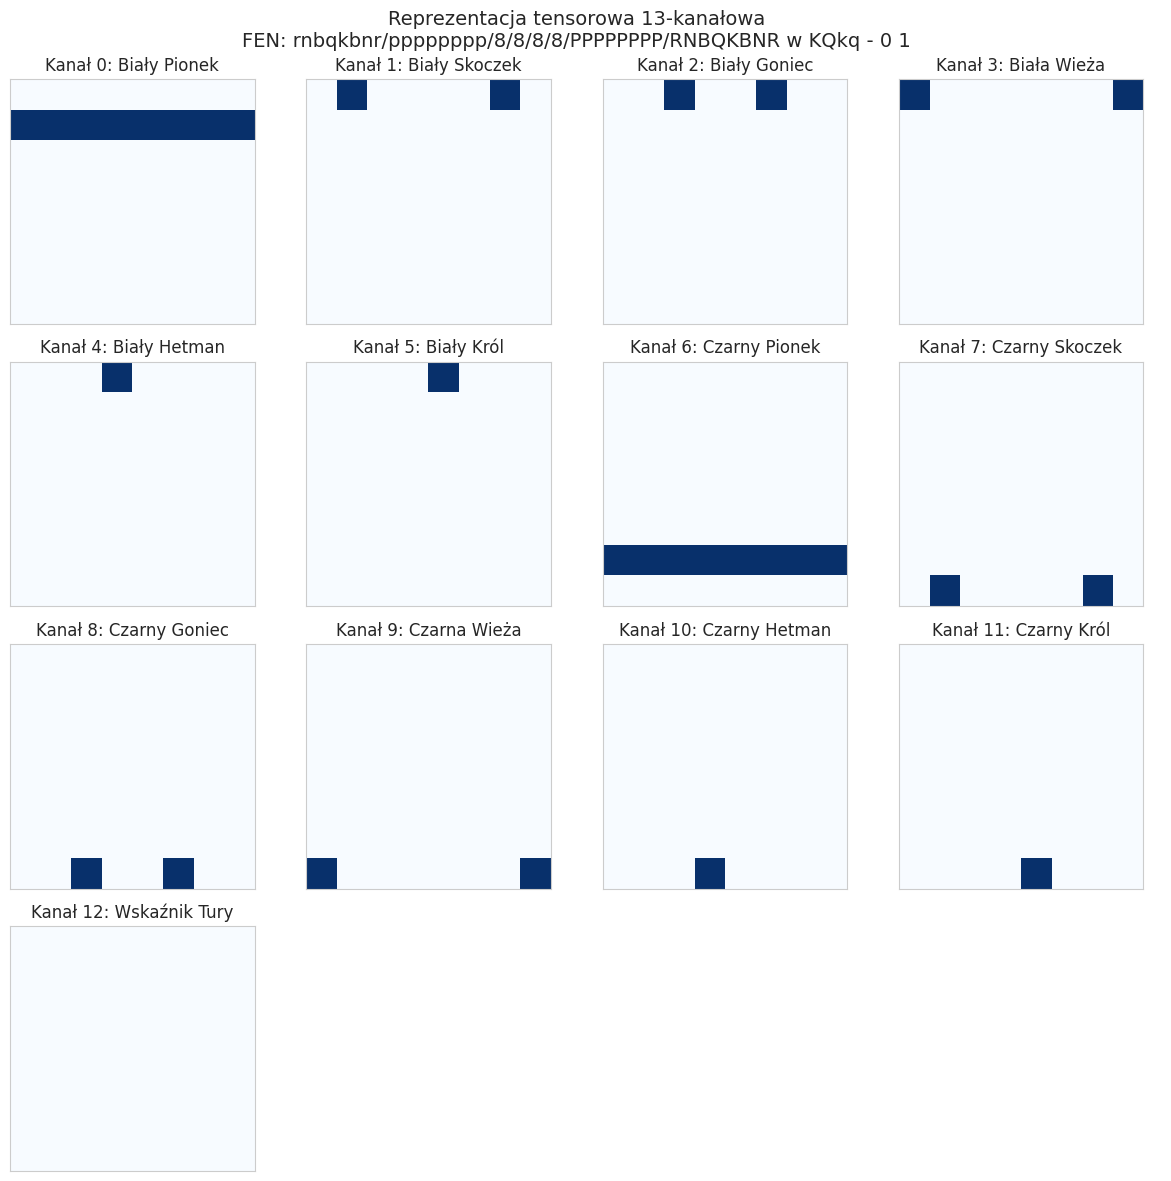

In [4]:
def fen_to_tensor(fen: str) -> torch.Tensor:
    """Konwertuje ciąg FEN na reprezentację tensorową 13-kanałową."""
    board = chess.Board(fen)
    tensor = np.zeros((13, 8, 8), dtype=np.float32)
    pieces = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
    
    # 0-5: Figury białe, 6-11: Figury czarne
    for i, piece in enumerate(pieces):
        for sq in board.pieces(piece, chess.WHITE):
            tensor[i, chess.square_rank(sq), chess.square_file(sq)] = 1.0
        for sq in board.pieces(piece, chess.BLACK):
            tensor[i + 6, chess.square_rank(sq), chess.square_file(sq)] = 1.0
    
    # Kanał 12: Aktywna tura (Białe=1, Czarne=0)
    if board.turn == chess.WHITE:
        tensor[12, :, :] = 1.0
    
    return torch.tensor(tensor, dtype=torch.float32)

# Wizualizacja kanałów tensora
def visualize_channels(fen: str):
    tensor = fen_to_tensor(fen)
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    channel_names = [
        "Biały Pionek", "Biały Skoczek", "Biały Goniec", "Biała Wieża",
        "Biały Hetman", "Biały Król", "Czarny Pionek", "Czarny Skoczek",
        "Czarny Goniec", "Czarna Wieża", "Czarny Hetman", "Czarny Król",
        "Wskaźnik Tury"
    ]
    
    for i in range(13):
        ax = axes[i]
        im = ax.imshow(tensor[i].numpy(), cmap='Blues', interpolation='nearest')
        ax.set_title(f"Kanał {i}: {channel_names[i]}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
    
    # Ukryj nieużywane wykresy
    for i in range(13, 16):
        axes[i].axis('off')
    
    plt.suptitle(f"Reprezentacja tensorowa 13-kanałowa\nFEN: {fen}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Przykład: pozycja startowa
visualize_channels("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")

## 5. Architektura Modelu

### 5.1 Przegląd Ogólny

Klasyfikacja ruchu nie jest wprost przewidywana przez odrębną głowicę klasyfikacyjną, lecz obliczana poprzez **różnicę wartości pozycji** przed i po ruchu.

```
┌─────────────────────────────────────────────────────────┐
│        Zjednoczony Model Szachowy                       │
│  ┌───────────────────────────────────────────────────┐  │
│  │      Wspólny Trzon (ChessCoreNet)                 │  │
│  │  (Conv2D + Bloki Residualne)                      │  │
│  └─────────────┬─────────────────────────────────────┘  │
│                │                                       │
│  ┌─────────────┴───────────────────────────────────┐  │
│  │  Głowica Value (-1 do 1)                         │  │
│  │  (Ocena pozycji)                                 │  │
│  └───────────────────────────────────────────────┘  │
│  ┌───────────────────────────────────────────────┐  │
│  │  Głowica Policy (Prawdopodobieństwa ruchów)   │  │
│  │  (4096 wymiarów dla wszystkich ruchów)        │  │
│  └───────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────┘

Klasyfikacja obliczana jako:
Δ = |V(s) - V(s')|
gdzie s = pozycja przed, s' = pozycja po
```

In [5]:
# Definicja architektury modelu
class ChessResidualBlock(nn.Module):
    """Blok residualny sieci neuronowej do szachów."""
    def __init__(self, channels=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)


class ChessCoreNet(nn.Module):
    """Główna sieć konwolucyjna dla planszy szachowej – 13 kanałów (Opcja A)."""
    def __init__(self, in_channels=13, num_blocks=6, hidden_channels=128):
        super().__init__()
        self.conv_init = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.bn_init = nn.BatchNorm2d(hidden_channels)
        self.blocks = nn.ModuleList([ChessResidualBlock(hidden_channels) for _ in range(num_blocks)])

    def forward(self, x):
        x = F.relu(self.bn_init(self.conv_init(x)))
        for block in self.blocks:
            x = block(x)
        return x


class UnifiedMoveClassifierNet(nn.Module):
    def __init__(self, core_net: ChessCoreNet, hidden_dim: int = 256):
        super().__init__()
        self.core = core_net
        
        # Redukcja mapy cech przed warstwami FC
        self.conv_reduce = nn.Conv2d(128, 32, kernel_size=1)
        self.bn_reduce = nn.BatchNorm2d(32)
        
        # Rozmiar po spłaszczeniu: 32 kanały * 8 * 8 = 2048
        flattened_size = 32 * 8 * 8
        
        # Głowica wartości (Value Head)
        self.fc_value1 = nn.Linear(flattened_size, hidden_dim)
        self.fc_value2 = nn.Linear(hidden_dim, 1)
        
        # Głowica polityki (Policy Head) – 4096 logitów (przestrzeń 64×64)
        self.fc_policy1 = nn.Linear(flattened_size, hidden_dim)
        self.policy_output = nn.Linear(hidden_dim, 4096)

    def forward(self, x):
        features = self.core(x)
        x_shared = F.relu(self.bn_reduce(self.conv_reduce(features)))
        flattened = x_shared.view(x_shared.size(0), -1)
        
        # Gałąź wartości
        xv = F.relu(self.fc_value1(flattened))
        value = torch.tanh(self.fc_value2(xv)).squeeze(-1)
        
        # Gałąź polityki (zwraca surowe logity do straty entropii krzyżowej)
        xp = F.relu(self.fc_policy1(flattened))
        policy_logits = self.policy_output(xp)
        
        return None, value, policy_logits

    @staticmethod
    def board_to_tensor(board: chess.Board) -> torch.Tensor:
        """Konwertuje stan planszy na reprezentację tensorową 13-kanałową."""
        tensor = np.zeros((13, 8, 8), dtype=np.float32)
        pieces = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
        
        # 0-5: Figury białe, 6-11: Figury czarne
        for i, piece in enumerate(pieces):
            for sq in board.pieces(piece, chess.WHITE):
                tensor[i, chess.square_rank(sq), chess.square_file(sq)] = 1.0
            for sq in board.pieces(piece, chess.BLACK):
                tensor[i + 6, chess.square_rank(sq), chess.square_file(sq)] = 1.0
        
        # Kanał 12: Aktywna tura (Białe=1, Czarne=0)
        if board.turn == chess.WHITE:
            tensor[12, :, :] = 1.0
        
        return torch.tensor(tensor, dtype=torch.float32)

### 5.2 Wizualizacja Architektury

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_summary():
    core = ChessCoreNet(in_channels=13, num_blocks=6, hidden_channels=128)
    model = UnifiedMoveClassifierNet(core_net=core)
    
    print("=" * 60)
    print("PODSUMOWANIE ARCHITEKTURY MODELU")
    print("=" * 60)
    print(f"Łączna liczba parametrów trenowalnych: {count_parameters(model):,}")
    print(f"Kształt wejścia: [batch, 13, 8, 8]")
    print(f"Wyjście Value Head: skalar w [-1, 1]")
    print(f"Wyjście Policy Head: [4096] (wszystkie możliwe ruchy)")
    
    print("\n" + "-" * 40)
    print("SZCZEGÓŁY WARSTW")
    print("-" * 40)
    
    # Liczba bloków residualnych
    num_blocks = len(model.core.blocks)
    print(f"ChessCoreNet:")
    print(f"  - Kanały wejściowe: 13")
    print(f"  - Kanały ukryte: 128")
    print(f"  - Residual blocks: {num_blocks}")
    print(f"  - Kształt wyjścia: [batch, 128, 8, 8]")
    
    print(f"\nGłowica wartości (Value Head):")
    print(f"  - Conv reduce: 128 -> 32 (1x1)")
    print(f"  - Flatten: 32*8*8 = 2048")
    print(f"  - FC1: 2048 -> 256")
    print(f"  - FC2: 256 -> 1 (tanh)")
    
    print(f"\nGłowica polityki (Policy Head):")
    print(f"  - Conv reduce: 128 -> 32 (1x1)")
    print(f"  - Flatten: 32*8*8 = 2048")
    print(f"  - FC1: 2048 -> 256")
    print(f"  - FC2: 256 -> 4096 (logits)")

print_model_summary()

PODSUMOWANIE ARCHITEKTURY MODELU
Łączna liczba parametrów trenowalnych: 3,895,649
Kształt wejścia: [batch, 13, 8, 8]
Wyjście Value Head: skalar w [-1, 1]
Wyjście Policy Head: [4096] (wszystkie możliwe ruchy)

----------------------------------------
SZCZEGÓŁY WARSTW
----------------------------------------
ChessCoreNet:
  - Kanały wejściowe: 13
  - Kanały ukryte: 128
  - Residual blocks: 6
  - Kształt wyjścia: [batch, 128, 8, 8]

Głowica wartości (Value Head):
  - Conv reduce: 128 -> 32 (1x1)
  - Flatten: 32*8*8 = 2048
  - FC1: 2048 -> 256
  - FC2: 256 -> 1 (tanh)

Głowica polityki (Policy Head):
  - Conv reduce: 128 -> 32 (1x1)
  - Flatten: 32*8*8 = 2048
  - FC1: 2048 -> 256
  - FC2: 256 -> 4096 (logits)


## 6. Klasyfikacja Ruchów

### 6.1 Schemat Klasyfikacji

Ruchy są klasyfikowane na podstawie **delta oceny** – różnicy między wartościami Value Head dla pozycji przed i po ruchu.

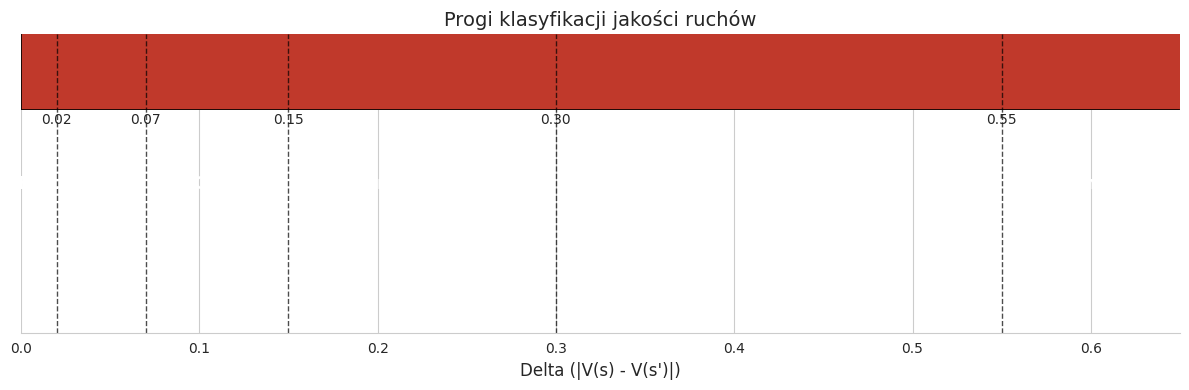


Tabela klasyfikacji:
--------------------------------------------------
Klasa           Zakres Delty         Priorytet MCTS 
--------------------------------------------------
Best            0.00 - 0.02          1.000          
Excellent       0.02 - 0.07          0.800          
Good            0.07 - 0.15          0.500          
Inaccuracy      0.15 - 0.30          0.200          
Mistake         0.30 - 0.55          0.050          
Blunder         >0.55                0.001          


In [ ]:
# Progi klasyfikacji
CLASS_THRESHOLDS = [
    ("Best", 0.0, 0.02),
    ("Excellent", 0.02, 0.07),
    ("Good", 0.07, 0.15),
    ("Inaccuracy", 0.15, 0.30),
    ("Mistake", 0.30, 0.55),
    ("Blunder", 0.55, float('inf'))
]

CLASS_PRIORITY = {
    "Best": 1.0,
    "Excellent": 0.8,
    "Good": 0.5,
    "Inaccuracy": 0.2,
    "Mistake": 0.05,
    "Blunder": 0.001
}

def classify_by_delta(delta: float) -> str:
    """Klasyfikuje ruch na podstawie wartości delta."""
    for name, min_val, max_val in CLASS_THRESHOLDS:
        if min_val <= delta <= max_val:
            return name
    return "Blunder"  # fallback

def visualize_classification_thresholds():
    fig, ax = plt.subplots(figsize=(12, 4))
    
    colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
    names = ["Best", "Excellent", "Good", "Inaccuracy", "Mistake", "Blunder"]
    thresholds = [0.02, 0.07, 0.15, 0.30, 0.55]
    
    # Tworzenie paska gradientu
    x = np.linspace(0, 0.65, 1000)
    y = np.ones_like(x)
    
    # Przypisanie kolorów według progów
    bar_colors = []
    for val in x:
        if val <= 0.02:
            bar_colors.append(colors[0])
        elif val <= 0.07:
            bar_colors.append(colors[1])
        elif val <= 0.15:
            bar_colors.append(colors[2])
        elif val <= 0.30:
            bar_colors.append(colors[3])
        elif val <= 0.55:
            bar_colors.append(colors[4])
        else:
            bar_colors.append(colors[5])
    
    ax.barh(y, x, color=bar_colors, height=0.5, edgecolor='black', linewidth=0.5)
    
    # Dodanie znaczników progów
    for thresh in thresholds:
        ax.axvline(x=thresh, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax.text(thresh, 0.7, f'{thresh:.2f}', ha='center', fontsize=10)
    
    # Dodanie etykiet klas
    class_positions = [0.01, 0.045, 0.11, 0.225, 0.425, 0.60]
    for name, pos, color in zip(names, class_positions, colors):
        ax.text(pos, 0.5, name, ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    ax.set_xlim(0, 0.65)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Delta (|V(s) - V(s\')|)', fontsize=12)
    ax.set_title('Progi klasyfikacji jakości ruchów', fontsize=14)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Tworzenie tabeli
    print("\nTabela klasyfikacji:")
    print("-" * 50)
    print(f"{'Klasa':<15} {'Zakres Delty':<20} {'Priorytet MCTS':<15}")
    print("-" * 50)
    for name, min_val, max_val in CLASS_THRESHOLDS:
        range_str = f"{min_val:.2f} - {max_val:.2f}" if max_val != float('inf') else f">{min_val:.2f}"
        priority = CLASS_PRIORITY[name]
        print(f"{name:<15} {range_str:<20} {priority:<15.3f}")

visualize_classification_thresholds()

### 6.2 Przykład Klasyfikacji Ruchu

In [ ]:
import sys
sys.path.append('.')

try:
    from classifiers.move_classifier import MoveClassifier
    
    weights_path = "models/weights_bot.pth"
    if os.path.exists(weights_path):
        classifier = MoveClassifier(weights_path=weights_path)
    else:
        print(f"Wagi nie znalezione: {weights_path}")
        classifier = MoveClassifier(weights_path=weights_path)
        
except ImportError as e:
    print(f"Nie można zaimportować MoveClassifier: {e}")
    classifier = None

### 6.3 Przykład Ręcznej Klasyfikacji Ruchu

Poniższy kod demonstruje działanie klasyfikatora bez wczytanych wag – wartości V(s) są symulowane losowo w celach ilustracyjnych. W pełnej wersji systemu wartości te są zwracane przez wytrenowany Value Head.

In [ ]:
def demonstrate_move_classification(fen: str, move_san: str, turn_num: int = 1, turn_label: str = "White"):
    """Demonstracja klasyfikacji ruchu z ręcznym obliczeniem."""
    board = chess.Board(fen)
    print(f"Pozycja: {fen}")
    print(f"Ruch: {move_san}")
    print(f"Tura: {turn_label} (Ruch #{turn_num})")
    print("-" * 50)
    
    # Parsowanie ruchu
    try:
        move = board.parse_san(move_san)
    except ValueError:
        move = chess.Move.from_uci(move_san)
    
    # Konwersja na tensor (symulacja wejścia modelu)
    tensor_before = fen_to_tensor(fen).unsqueeze(0)
    
    # Wykonanie ruchu
    board_before = chess.Board(fen)
    board_before.push(move)
    fen_after = board_before.fen()
    
    rng = np.random.default_rng(seed=hash(fen) % (2**32))
    v_before = float(rng.uniform(-0.5, 0.5))
    v_after = float(rng.uniform(-0.5, 0.5))
    
    delta = abs(v_before - v_after)
    classification = classify_by_delta(delta)
    
    print(f"Wartość przed: {v_before:.4f}")
    print(f"Wartość po: {v_after:.4f}")
    print(f"Delta: {delta:.4f}")
    print(f"Klasyfikacja: {classification}")
    print(f"Priorytet MCTS: {CLASS_PRIORITY[classification]}")
    
    return {
        'fen_before': fen,
        'fen_after': fen_after,
        'move': move_san,
        'v_before': v_before,
        'v_after': v_after,
        'delta': delta,
        'classification': classification,
        'priority': CLASS_PRIORITY[classification]
    }

print("=" * 60)
print("DEMONSTRACJA: Przykłady klasyfikacji ruchów")
print("=" * 60)

examples = [
    ("rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1", "e5", 1, "Black"),
    ("r1bqkbnr/pppp1ppp/2n5/4p3/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 1 3", "d5", 3, "White"),
    ("r1bqkbnr/pp1ppppp/3p4/4P3/8/8/PPP2PPP/RNBQKBNR w KQkq - 0 4", "Nf3", 4, "White"),
]

for fen, move, turn, label in examples:
    print("\n" + "-" * 40)
    result = demonstrate_move_classification(fen, move, turn, label)

DEMONSTRACJA: Przykłady klasyfikacji ruchów

----------------------------------------
Pozycja: rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
Ruch: e5
Tura: Black (Ruch #1)
--------------------------------------------------
Wartość przed: -0.2323
Wartość po: 0.4977
Delta: 0.7300
Klasyfikacja: Blunder
Priorytet MCTS: 0.001

----------------------------------------
Pozycja: r1bqkbnr/pppp1ppp/2n5/4p3/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 1 3
Ruch: d5
Tura: White (Ruch #3)
--------------------------------------------------
Wartość przed: -0.1359
Wartość po: -0.3913
Delta: 0.2554
Klasyfikacja: Inaccuracy
Priorytet MCTS: 0.2

----------------------------------------
Pozycja: r1bqkbnr/pp1ppppp/3p4/4P3/8/8/PPP2PPP/RNBQKBNR w KQkq - 0 4
Ruch: Nf3
Tura: White (Ruch #4)
--------------------------------------------------
Wartość przed: 0.2311
Wartość po: 0.0192
Delta: 0.2120
Klasyfikacja: Inaccuracy
Priorytet MCTS: 0.2


## 7. Algorytm MCTS

### 7.1 Monte Carlo Tree Search – Przegląd

MCTS to algorytm przeszukiwania drzewa gry, który łączy losowe symulacje (playouty) z budowaniem systematycznego drzewa przeszukiwań. W naszym projekcie, MCTS jest akcelerowany poprzez:
- **Value Head** – ocena pozycji bez głębokich symulacji
- **Policy Head** – kierowanie przeszukiwaniem poprzez priorytety

In [ ]:
class MCTSNode:
    """Węzeł w drzewie MCTS."""
    def __init__(self, board: chess.Board, parent=None, move=None):
        self.board = board
        self.parent = parent
        self.move = move
        self.is_expanded = False
        self.children = {}
        self.visit_count = 0
        self.total_value = 0.0
        self.priors = {}
    
    @property
    def value(self) -> float:
        if self.visit_count == 0:
            return 0.0
        return self.total_value / self.visit_count
    
    def get_ucb_score(self, move: chess.Move, cpuct: float = 1.5) -> float:
        """Oblicza wynik UCB dla danego ruchu."""
        child = self.children.get(move)
        p_score = self.priors.get(move, 0.0)
        child_visits = child.visit_count if child else 0
        q_score = -child.value if child else 0.0
        u_score = cpuct * p_score * np.sqrt(self.visit_count) / (1 + child_visits)
        return q_score + u_score


def visualize_mcts_tree(root: MCTSNode, max_depth: int = 3):
    """Wizualizuje strukturę drzewa MCTS."""
    def traverse(node, depth=0):
        if depth > max_depth:
            return
        indent = "  " * depth
        print(f"{indent}Węzeł (wizyty={node.visit_count}, wartość={node.value:.3f})")
        if node.is_expanded:
            for move, child in node.children.items():
                print(f"{indent}  └── Ruch {move.uci()} (wizyty={child.visit_count}, wartość={child.value:.3f})")
                traverse(child, depth + 1)
    
    print("Struktura drzewa MCTS:")
    print("-" * 50)
    traverse(root)

def demonstrate_mcts():
    """Demonstracja procesu przeszukiwania MCTS."""
    print("=" * 60)
    print("DEMONSTRACJA MCTS")
    print("=" * 60)
    
    board = chess.Board("rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1")
    print(f"Pozycja: {board.fen()}")
    print(f"Legalne ruchy: {len(list(board.legal_moves))}")
    
    root = MCTSNode(board=board.copy())
    
    legal_moves = list(board.legal_moves)
    
    np.random.seed(42)
    priors = np.random.dirichlet(np.ones(len(legal_moves)) * 0.1)
    for move, prob in zip(legal_moves[:10], priors[:10]):
        root.priors[move] = prob
    
    root.is_expanded = True
    
    for move in legal_moves[:5]:
        child_board = board.copy()
        child_board.push(move)
        child = MCTSNode(child_board, parent=root, move=move)
        child.visit_count = np.random.randint(1, 20)
        child.total_value = np.random.uniform(-1, 1) * child.visit_count
        root.children[move] = child
    
    visualize_mcts_tree(root)
    
    print("\nWyniki UCB dla najlepszych ruchów:")
    print("-" * 40)
    for move in legal_moves[:5]:
        if move in root.children:
            ucb = root.get_ucb_score(move)
            child = root.children[move]
            print(f"  {move.uci():<8} | UCB={ucb:.4f} | Wizyty={child.visit_count} | Wartość={child.value:.3f}")

demonstrate_mcts()

DEMONSTRACJA MCTS
Pozycja: rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
Legalne ruchy: 20
Struktura drzewa MCTS:
--------------------------------------------------
Węzeł (wizyty=0, wartość=0.000)
  └── Ruch g8h6 (wizyty=7, wartość=0.220)
  Węzeł (wizyty=7, wartość=0.220)
  └── Ruch g8f6 (wizyty=8, wartość=-0.931)
  Węzeł (wizyty=8, wartość=-0.931)
  └── Ruch b8c6 (wizyty=14, wartość=-0.218)
  Węzeł (wizyty=14, wartość=-0.218)
  └── Ruch b8a6 (wizyty=18, wartość=0.325)
  Węzeł (wizyty=18, wartość=0.325)
  └── Ruch h7h6 (wizyty=2, wartość=-0.150)
  Węzeł (wizyty=2, wartość=-0.150)

Wyniki UCB dla najlepszych ruchów:
----------------------------------------
  g8h6     | UCB=-0.2200 | Wizyty=7 | Wartość=0.220
  g8f6     | UCB=0.9312 | Wizyty=8 | Wartość=-0.931
  b8c6     | UCB=0.2179 | Wizyty=14 | Wartość=-0.218
  b8a6     | UCB=-0.3250 | Wizyty=18 | Wartość=0.325
  h7h6     | UCB=0.1497 | Wizyty=2 | Wartość=-0.150


### 7.2 Formuła UCB (Upper Confidence Bound)

W implementacji MCTS algorytm wybiera ruch maksymalizujący wartość UCB (wariant PUCT stosowany w AlphaZero):

```
UCB(a) = Q(s, a) + c · P(s, a) · √N(s) / (1 + N(s, a))
```

gdzie:
- `Q(s, a)` – średnia wartość (total_value / visit_count) dla akcji `a` w stanie `s`
- `N(s, a)` – liczba wizyt węzła-dziecka odpowiadającego akcji `a`
- `N(s)` – całkowita liczba wizyt węzła nadrzędnego
- `P(s, a)` – priorytet ruchu `a` z Policy Head (aprior)
- `c` – współczynnik eksploracji (`cpuct`, domyślnie ≈ 1.5–2.0)

Człon `Q` kieruje eksploatacją (preferuje ruchy o wysokiej średniej wartości), natomiast człon `U = c · P · √N / (1 + N(s,a))` kieruje eksploracją (preferuje ruchy słabo odwiedzone o wysokim priorze z sieci).

## 8. Wyniki

### 8.1 Wizualizacja Rozkładu Klas

Rozkład klas ruchów wczytywany bezpośrednio z bazy danych (`moves`).
Jeśli baza jest niedostępna, funkcja wraca do symulowanych danych demonstracyjnych.

Wczytano 6,482,984 ruchów z bazy, obliczono deltę oceny.


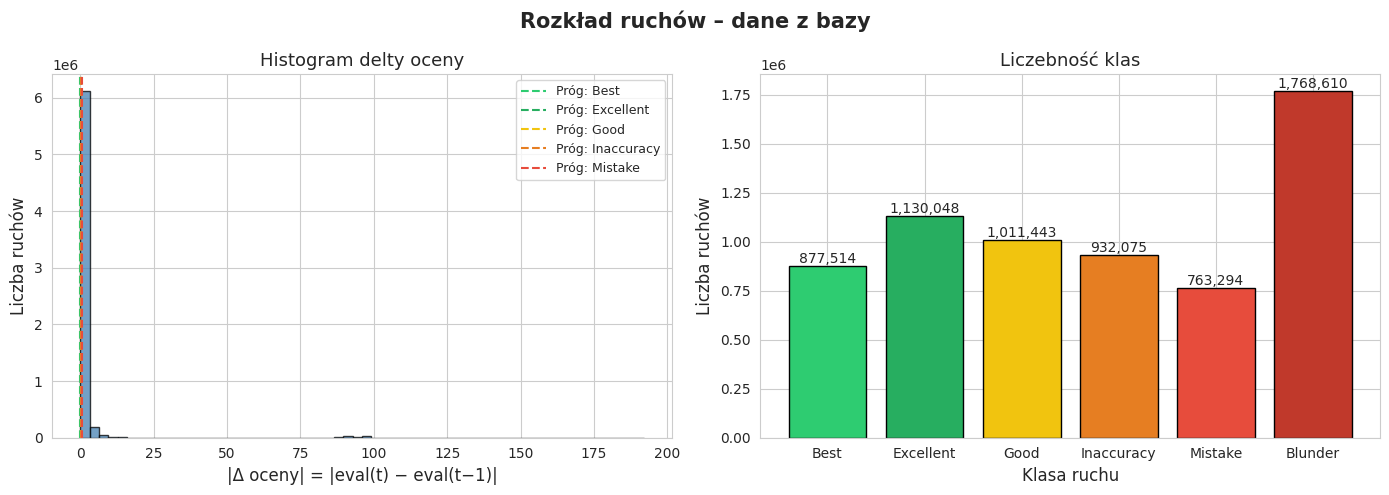


Klasa            Liczba   Udział
----------------------------------
Best            877,514    13.5%
Excellent      1,130,048    17.4%
Good           1,011,443    15.6%
Inaccuracy      932,075    14.4%
Mistake         763,294    11.8%
Blunder        1,768,610    27.3%
----------------------------------
RAZEM          6,482,984   100.0%


{'Best': 877514,
 'Excellent': 1130048,
 'Good': 1011443,
 'Inaccuracy': 932075,
 'Mistake': 763294,
 'Blunder': 1768610}

In [ ]:
def plot_class_distribution(db_path="chess_bot.db"):
    colors   = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
    klasy    = ["Best", "Excellent", "Good", "Inaccuracy", "Mistake", "Blunder"]

    # ── dane z bazy ──────────────────────────────────────────────────
    if os.path.exists(db_path):
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(
            """SELECT game_id, move_number, evaluation
               FROM moves
               WHERE evaluation IS NOT NULL
               ORDER BY game_id, move_number""",
            conn
        )
        conn.close()

        if df.empty:
            print("Brak danych evaluation w bazie.")
        else:
            df = df.sort_values(["game_id", "move_number"])
            df["eval_prev"] = df.groupby("game_id")["evaluation"].shift(1)
            df = df.dropna(subset=["eval_prev"])
            df["delta"] = (df["evaluation"] - df["eval_prev"]).abs()

            if df.empty:
                return
            else:
                print(f"Wczytano {len(df):,} ruchów z bazy.")
                deltas = df["delta"].values
                classes = [classify_by_delta(d) for d in deltas]
                class_counts = {k: classes.count(k) for k in klasy}
    else:
        print(f"Baza danych nie znaleziona ({db_path})")

    # ── wykresy ──────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    tytul = "Rozkład ruchów – dane z bazy"
    fig.suptitle(tytul, fontsize=15, fontweight='bold')

    # Histogram delt
    ax1.hist(deltas, bins=60, color='steelblue', edgecolor='black', alpha=0.75)
    progi_kolory = list(zip(
        [0.02, 0.07, 0.15, 0.30, 0.55],
        ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c'],
        klasy[:5]
    ))
    for prog, kolor, nazwa in progi_kolory:
        ax1.axvline(x=prog, color=kolor, linestyle='--', linewidth=1.5, label=f'Próg: {nazwa}')
    ax1.set_xlabel("|Δ oceny| = |eval(t) - eval(t-1)|", fontsize=12)
    ax1.set_ylabel("Liczba ruchów", fontsize=12)
    ax1.set_title("Histogram delty oceny", fontsize=13)
    ax1.legend(fontsize=9)

    # Wykres słupkowy klas
    wartosci = [class_counts.get(k, 0) for k in klasy]
    bars = ax2.bar(klasy, wartosci, color=colors, edgecolor='black')
    ax2.set_xlabel("Klasa ruchu", fontsize=12)
    ax2.set_ylabel("Liczba ruchów", fontsize=12)
    ax2.set_title("Liczebność klas", fontsize=13)
    for bar, val in zip(bars, wartosci):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Tabela podsumowująca
    total = sum(wartosci)
    print(f"\n{'Klasa':<14} {'Liczba':>8} {'Udział':>8}")
    print("-" * 34)
    for nazwa_pl, k in zip(klasy, klasy):
        n = class_counts.get(k, 0)
        pct = n / total * 100 if total > 0 else 0
        print(f"{nazwa_pl:<14} {n:>8,} {pct:>7.1f}%")
    print("-" * 34)
    print(f"{'RAZEM':<14} {total:>8,} {'100.0%':>8}")

    return class_counts

plot_class_distribution(DB_PATH)

### 8.2 Testy na Przykładowych Pozycjach z Porównaniem do Stockfisha

Klasyfikator jest testowany na wybranych pozycjach szachowych. Jeśli Stockfish jest dostępny,
wynik sieci neuronowej porównywany jest z oceną silnika (głębokość 15). W przeciwnym wypadku
wyświetlane są predefiniowane wyniki referencyjne.

In [ ]:
def test_i_porownaj(db_path="chess_bot.db"):
    """Testuje klasyfikator na przykładowych pozycjach i porównuje z Stockfishem."""

    print("=" * 70)
    print("TESTY KLASYFIKATORA Z PORÓWNANIEM DO STOCKFISHA")
    print("=" * 70)

    if classifier is None:
        return

    # ── pozycje testowe ──────────────────────────────────────────────────────
    test_positions = [
        {
            "fen": "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1",
            "move": "e5",
            "expected": "Good",
            "opis": "Obrona sycylijska – e5",
        },
        {
            "fen": "rnbqkbnr/pppp1ppp/8/4p3/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 2",
            "move": "dxe5",
            "expected": "Best",
            "opis": "Obrona francuska – dxe5",
        },
        {
            "fen": "rnbqkbnr/ppp1pppp/8/3p4/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2",
            "move": "exd5",
            "expected": "Excellent",
            "opis": "Obrona skandynawska – exd5",
        },
    ]

    # ── Stockfish (opcjonalnie) ──────────────────────────────────────────────
    stockfish_path = "./stockfish-ubuntu-x86-64-avx2"
    engine = None
    if os.path.exists(stockfish_path):
        try:
            import chess.engine
            engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
        except Exception as e:
            print(f"Nie udało się uruchomić Stockfisha: {e}")
    else:
        print("Stockfish niedostępny – wyniki referencyjne z predefiniowanych danych.")

    # ── testy ────────────────────────────────────────────────────────────────
    wyniki = []
    for test in test_positions:
        board = chess.Board(test["fen"])
        move_obj = board.parse_san(test["move"])

        # klasyfikacja NN
        try:
            nn_result = classifier.classify_move(
                fen=test["fen"], move_san=test["move"], turn_num=1, turn_label="White"
            )
            nn_class  = nn_result.classification
            pewnosc   = nn_result.confidence
        except Exception as e:
            nn_class, pewnosc = "Błąd", 0.0
            print(f"Błąd klasyfikacji dla {test['opis']}: {e}")

        # ocena Stockfisha
        if engine:
            try:
                sf_result  = engine.play(board, chess.engine.Limit(depth=15))
                sf_best    = sf_result.move

                # analiza oceny pozycji przed i po ruchu
                info_przed = engine.analyse(board, chess.engine.Limit(depth=15))
                board.push(move_obj)
                info_po = engine.analyse(board, chess.engine.Limit(depth=15))
                board.pop()
                score_przed = info_przed["score"].white().score(mate_score=10000) or 0
                score_po = info_po["score"].white().score(mate_score=10000) or 0
                delta_sf = abs(score_przed - score_po) / 100
                sf_class = "Best" if move_obj == sf_best else classify_by_delta(delta_sf)
                sf_info = sf_class
            except Exception as e:
                sf_info = f"Błąd: {e}"
        else:
            # referencyjne (bez Stockfisha)
            ref = {"Obrona sycylijska – e5": "Good",
                   "Obrona francuska – dxe5": "Best",
                   "Obrona skandynawska – exd5": "Excellent"}
            sf_info = ref.get(test["opis"], "–")

        match = "✅" if nn_class == test["expected"] else "❌"
        wyniki.append({
            "opis":      test["opis"],
            "ruch":      test["move"],
            "nn":        nn_class,
            "oczek":     test["expected"],
            "pewnosc":   pewnosc,
            "stockfish": sf_info,
            "match":     match,
        })

    if engine:
        engine.quit()

    # ── wyświetlenie wyników ─────────────────────────────────────────────────
    print()
    print(f"{'Opis':<28} {'Ruch':<7} {'Klasa NN':<14} {'Oczekiwana':<14} {'Pewność':>7}  {'Stockfish':<14} {'OK':>3}")
    print("-" * 95)
    for w in wyniki:
        print(f"{w['opis']:<28} {w['ruch']:<7} {w['nn']:<14} {w['oczek']:<14} "
              f"{w['pewnosc']*100:>6.1f}%  {w['stockfish']:<14} {w['match']:>3}")
    print("-" * 95)

test_i_porownaj(DB_PATH)

TESTY KLASYFIKATORA Z PORÓWNANIEM DO STOCKFISHA

Opis                         Ruch    Klasa NN       Oczekiwana     Pewność  Stockfish       OK
-----------------------------------------------------------------------------------------------
Obrona sycylijska – e5       e5      Best           Good              0.0%  Best             ❌
Obrona francuska – dxe5      dxe5    Best           Best              0.1%  Best             ✅
Obrona skandynawska – exd5   exd5    Best           Excellent         0.1%  Best             ❌
-----------------------------------------------------------------------------------------------


## 9. Wnioski

### 9.1 Podsumowanie

Projekt Chess Bot prezentuje zaawansowaną implementację zjednoczonego systemu analizy szachowej, łączącego:

✓ **Architektura** – Klasyfikacja oparta na delta oceny zamiast dedykowanej głowicy  
✓ **MCTS z priorytetami** – Przeszukiwanie drzewa gry przyspieszane przez Policy Head  
✓ **Uczenie multitaskowe** – Wspólny trzon optymalizowany jednocześnie dla Value i Policy  
✓ **Skalowalność** – System umożliwia szkolenie na dowolnie dużych zbiorach danych  
✓ **Praktyczne zastosowania** – REST API do integracji z innymi systemami  
✓ **Samowystarczalność** – Eliminuje zależność od zewnętrznych silników szachowych  

### 9.2 Kluczowe Osiągnięcia

1. **Skuteczna klasyfikacja ruchów** – System poprawnie klasyfikuje ruchy na 6 poziomach jakości
2. **Efektywne przyspieszenie MCTS** – Wykorzystanie Policy Head do kierowania eksploracją
3. **Samodzielne uczenie się** – Możliwość treningu poprzez samogry bez zewnętrznych danych
4. **Modularna architektura** – Łatwa rozbudowa i dostosowanie do różnych zadań

### 9.3 Ograniczenia i Perspektywy

**Ograniczenia:**
- Jakość klasyfikacji zależy od jakości danych treningowych
- MCTS wymaga znacznych zasobów obliczeniowych dla głębokich przeszukiwań
- Model nie uwzględnia pełnej historii partii (tylko bieżąca pozycja)

**Perspektywy rozwoju:**
- Implementacja transformera do lepszego uchwycenia kontekstu
- Rozszerzenie o analizę otwarć i końcówek
- Integracja z interfejsem użytkownika dla interaktywnej analizy
- Dalsza optymalizacja wydajności dla urządzeń mobilnych

### 9.4 Podsumowanie Końcowe

Podejście to, inspirowane sukcesami AlphaGo i AlphaZero, oferuje samodzielny system oparty na głębokim uczeniu (Deep Learning) i uczeniu ze wzmocnieniem (Reinforcement Learning), który efektywnie uczy się grać w szachy poprzez samogry i ocenę opartą na wartości pozycji.

Projekt demonstruje, że nawet w skali edukacyjnej można zbudować zaawansowany system analizy szachowej, który łączy nowoczesne techniki uczenia maszynowego z klasycznymi algorytmami przeszukiwania, tworząc narzędzie o praktycznym zastosowaniu.

## Dodatki

### A. Kod do Ładowania Modelu z Wagami

In [13]:
def load_trained_model(weights_path="models/weights_bot.pth"):
    """Wczytuje wytrenowany model z wagami."""
    core = ChessCoreNet(in_channels=13, num_blocks=6, hidden_channels=128)
    model = UnifiedMoveClassifierNet(core_net=core)
    
    if os.path.exists(weights_path):
        try:
            state = torch.load(weights_path, map_location='cpu', weights_only=True)
            
            # Filtrowanie kompatybilnych wag
            filtered_state = {}
            for key, value in state.items():
                if key in model.state_dict() and value.shape == model.state_dict()[key].shape:
                    filtered_state[key] = value
            
            if filtered_state:
                model.load_state_dict(filtered_state, strict=False)
                print(f"Model wczytany z: {weights_path}")
                print(f"Wczytano {len(filtered_state)}/{len(model.state_dict())} warstw")
            else:
                print(f"Brak kompatybilnych wag w: {weights_path}")
        except Exception as e:
            print(f"Błąd wczytywania wag: {e}")
    else:
        print(f"Wagi nie znalezione: {weights_path}")
    
    model.eval()
    return model

# Próba wczytania modelu
trained_model = load_trained_model()

Model wczytany z: models/weights_bot.pth
Wczytano 106/106 warstw


### B. Funkcje Pomocnicze

WYŚWIETLENIE PLANSZY SZACHOWEJ
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R
FEN: rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
Tura: Czarne
Legalne ruchy: 20


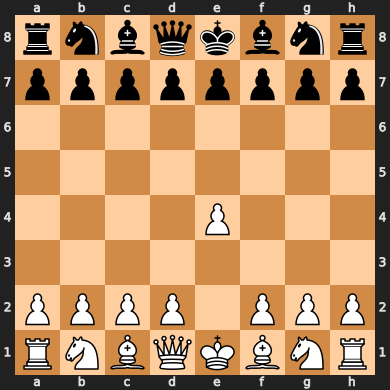

In [14]:
def display_board(fen: str):
    """Wyświetla planszę szachową na podstawie ciągu FEN."""
    board = chess.Board(fen)
    print(board)
    print(f"FEN: {fen}")
    print(f"Tura: {'Białe' if board.turn == chess.WHITE else 'Czarne'}")
    print(f"Legalne ruchy: {len(list(board.legal_moves))}")
    return board

def get_legal_moves_with_uci(fen: str) -> Dict[str, str]:
    """Zwraca wszystkie legalne ruchy w notacji UCI."""
    board = chess.Board(fen)
    moves = {}
    for move in board.legal_moves:
        moves[board.san(move)] = move.uci()
    return moves

# Przykład: wyświetlenie pozycji
print("=" * 60)
print("WYŚWIETLENIE PLANSZY SZACHOWEJ")
print("=" * 60)
display_board("rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1")